In [1]:
import jax
import jax.numpy as jnp

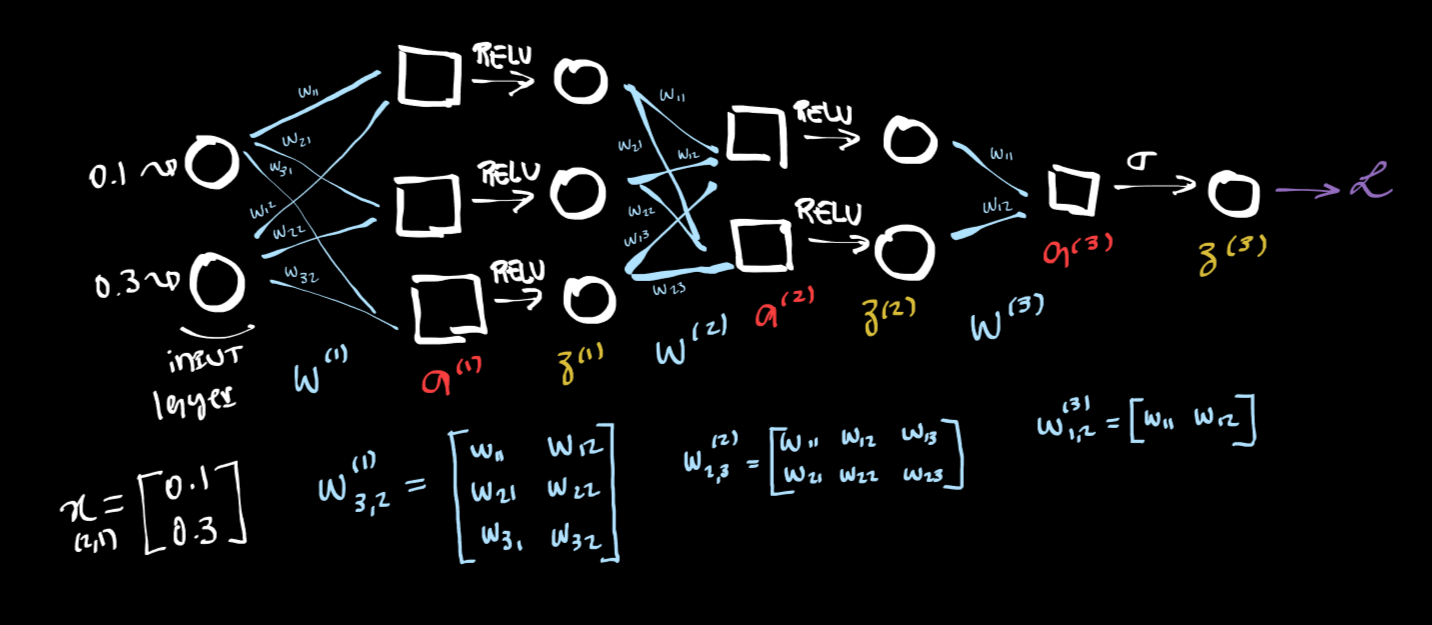

In [2]:
def log_loss(y_true, y_pred):
    eps = 1e-7
    y_pred = jnp.clip(y_pred, eps, 1 - eps)
    return -jnp.mean(
        y_true * jnp.log(y_pred) +
        (1 - y_true) * jnp.log(1 - y_pred)
    )

In [3]:
# target
y = jnp.array([[1.0]])

In [4]:
# input da rede
x = jnp.array([
    [0.1], 
    [0.9]
])
print(x)

[[0.1]
 [0.9]]


In [5]:
# Pesos da rede
W_1 = jnp.array([
    [0.1, 0.2],
    [0.1, 0.2],
    [0.1, 0.2]
])
print('W⁽¹⁾:')
print(W_1)
print('-' * 3)
W_2 = jnp.array([
    [0.1, 0.2, 0.3],
    [0.1, 0.2, 0.3],
])
print('W⁽²⁾:')
print(W_2)
print('-' * 3)
W_3 = jnp.array([[0.1, 0.2]])
print('W⁽³⁾:')
print(W_3)

W⁽¹⁾:
[[0.1 0.2]
 [0.1 0.2]
 [0.1 0.2]]
---
W⁽²⁾:
[[0.1 0.2 0.3]
 [0.1 0.2 0.3]]
---
W⁽³⁾:
[[0.1 0.2]]


In [6]:
# ∑ primeira camada
a_1 = W_1 @ x
print('a⁽¹⁾:')
print(a_1)

a⁽¹⁾:
[[0.19]
 [0.19]
 [0.19]]


In [7]:
# função de ativação f(x) primeira camada
z_1 = jax.nn.relu(a_1)
print('z⁽¹⁾:')
print(z_1)

z⁽¹⁾:
[[0.19]
 [0.19]
 [0.19]]


In [8]:
# ∑ segunda camada
a_2 = W_2 @ z_1
print('a⁽²⁾:')
print(a_2)

a⁽²⁾:
[[0.11399999]
 [0.11399999]]


In [9]:
# função de ativação f(x) segunda camada
z_2 = jax.nn.relu(a_2)
print('z⁽²⁾:')
print(z_2)

z⁽²⁾:
[[0.11399999]
 [0.11399999]]


In [10]:
# ∑ ultima camada
a_3 = W_3 @ z_2
print('a⁽³⁾:')
print(a_3)

a⁽³⁾:
[[0.0342]]


In [11]:
# função de ativação f(x) ultima camada
z_3 = jax.nn.sigmoid(a_3)
print('z⁽³⁾:')
print(z_3)

z⁽³⁾:
[[0.50854915]]


In [12]:
loss = log_loss(y, z_3)

In [13]:
print(f'Loss: {loss.item():.2f}')

Loss: 0.68


In [14]:
# calculando os deltas (δ) erro de cada neuronio
# dLoss / dz_3
δ_z3 = z_3 - y

In [15]:
print(f'δ_z3: {δ_z3.item():.4f}')

δ_z3: -0.4915


In [16]:
# dz_3 / da_3
# z_3 = sigmoid(a_3)
# z_3(a_3) = 1 / 1 + e^-(a_3) → É isso que vamos derivar
dz3_da3 = z_3 * (1 - z_3)

In [17]:
dz3_da3
print(f'dz3_da3: {dz3_da3.item():.4f}')

dz3_da3: 0.2499


In [18]:
δ_a3 = dz3_da3 * δ_z3

In [19]:
print(f'δ_a3: {δ_a3.item():.4f}')

δ_a3: -0.1228


In [20]:
# save for later
# Esse é o dLoss/dW que vamos atualizar depois
gradients_W_3 = δ_a3 * z_2
gradients_W_3

Array([[-0.01400225],
       [-0.01400225]], dtype=float32)

In [21]:
δ_z2 = (δ_a3 * W_3).reshape(-1, 1)
print(f'δ_z2:\n {δ_z2}')

δ_z2:
 [[-0.01228268]
 [-0.02456536]]


In [22]:
# derivada da ReLU
dz2_da2 = (a_2 > 0).astype(jnp.float32)
print(f'dz2_da2:\n {dz2_da2}')

dz2_da2:
 [[1.]
 [1.]]


In [23]:
δ_a2 = δ_z2 * dz2_da2  
print(f'δ_a2:\n {δ_a2}')

δ_a2:
 [[-0.01228268]
 [-0.02456536]]


In [24]:
# save for later
# Esse é o dLoss/dW que vamos atualizar depois
gradients_W_2 = δ_a2 * z_1.T
gradients_W_2

Array([[-0.00233371, -0.00233371, -0.00233371],
       [-0.00466742, -0.00466742, -0.00466742]], dtype=float32)

In [25]:
δ_z1 = (δ_a2 * W_2)  # reshape(-1, 1)
# devemos somar pois aqui tem o impacto desse neuronio para os próximos
# por isso somamos
δ_z1 = δ_z1.sum(axis=0)
δ_z1 = δ_z1.reshape(-1, 1)
print(f'δ_z1:\n {δ_z1}')

δ_z1:
 [[-0.0036848 ]
 [-0.00736961]
 [-0.01105441]]


In [26]:
# derivada da ReLU
dz1_da1 = (a_1 > 0).astype(jnp.float32)
print(f'dz1_da1:\n {dz1_da1}')

dz1_da1:
 [[1.]
 [1.]
 [1.]]


In [27]:
δ_a1 = δ_z1 * dz1_da1
print(f'δ_a1:\n {δ_a1}')

δ_a1:
 [[-0.0036848 ]
 [-0.00736961]
 [-0.01105441]]


In [28]:
δ_a1.shape

(3, 1)

In [29]:
x.T

Array([[0.1, 0.9]], dtype=float32)

In [30]:
# save for later
gradients_W_1 = δ_a1 * x.T
gradients_W_1

Array([[-0.00036848, -0.00331632],
       [-0.00073696, -0.00663265],
       [-0.00110544, -0.00994897]], dtype=float32)

In [31]:
W_3.shape

(1, 2)

In [32]:
gradients_W_3.shape

(2, 1)

In [33]:
W_3 - 1 * gradients_W_3.T

Array([[0.11400226, 0.21400225]], dtype=float32)

In [34]:
W_2.shape

(2, 3)

In [35]:
W_3 = W_3 - 1 * gradients_W_3.T
W_3

Array([[0.11400226, 0.21400225]], dtype=float32)

In [36]:
W_2 = W_2 - 1 * gradients_W_2
W_2

Array([[0.10233371, 0.20233372, 0.3023337 ],
       [0.10466742, 0.20466742, 0.30466744]], dtype=float32)

In [37]:
W_1 = W_1 - 1 * gradients_W_1
W_1

Array([[0.10036848, 0.20331633],
       [0.10073696, 0.20663264],
       [0.10110544, 0.20994897]], dtype=float32)

In [38]:
# recalculando a Loss
a_1 = W_1 @ x
print('a⁽¹⁾:')
print(a_1)

a⁽¹⁾:
[[0.19302154]
 [0.19604306]
 [0.19906461]]


In [39]:
z_1 = jax.nn.relu(a_1)
print('z⁽¹⁾:')
print(z_1)

z⁽¹⁾:
[[0.19302154]
 [0.19604306]
 [0.19906461]]


In [40]:
a_2 = W_2 @ z_1
print('a⁽²⁾:')
print(a_2)

a⁽²⁾:
[[0.11960267]
 [0.1209752 ]]


In [41]:
z_2 = jax.nn.relu(a_2)
print('z⁽²⁾:')
print(z_2)

z⁽²⁾:
[[0.11960267]
 [0.1209752 ]]


In [42]:
a_3 = W_3 @ z_2
print('a⁽³⁾:')
print(a_3)

a⁽³⁾:
[[0.03952394]]


In [43]:
z_3 = jax.nn.sigmoid(a_3)
print('z⁽³⁾:')
print(z_3)

z⁽³⁾:
[[0.5098797]]


In [44]:
loss_new = log_loss(y, z_3)

In [45]:
print(f'Loss: {loss_new.item():.2f}')

Loss: 0.67


In [46]:
Δ_loss = ((loss - loss_new) / loss_new) * 100

In [47]:
print(f'loss: {Δ_loss.item():.2f}% smallest.')

loss: 0.39% smallest.


In [48]:
# Treinamento do modelo
EPOCHS = 500
# Learning Rate
η = 1
for epoch in range(EPOCHS):
    # Erro do ultimo neuronio (após sigmoid)
    δ_z3 = z_3 - y
    # Erro da somatória do ultimo neuronio (antes da sigmoid)
    dz3_da3 = z_3 * (1 - z_3)
    δ_a3 = dz3_da3 * δ_z3
    # Calculando os Gradientes para atualização da matriz W_3
    gradients_W_3 = δ_a3 * z_2

    # Erros dos dois neuronios antes do neuronio de saída
    δ_z2 = δ_a3 * W_3
    # derivada da ReLU
    δ_a2 = δ_z2.T * (a_2 > 0).astype(jnp.float32)
    # Calculando os Gradientes para atualização da matriz W_2
    gradients_W_2 = δ_a2 * z_1.T

    # Erros dos três neuronios antes do neuronio de saída
    δ_z1 = (δ_a2 * W_2).T
    # Fazemos a soma pois um neuronio na camada (1) impacta dois da próxima camada
    δ_z1 = δ_z1.sum(axis=1)
    # derivada da ReLU
    δ_a1 = δ_z1 * (a_1.reshape(-1) > 0).astype(jnp.float32)
    # Calculando os Gradientes para atualização da matriz W_1
    gradients_W_1 = δ_a1.reshape(3, 1) * x.T

    # Atualização dos pesos
    W_3 = W_3 - η * gradients_W_3.T
    W_2 = W_2 - η * gradients_W_2
    W_1 = W_1 - η * gradients_W_1

    # Forward: Já fizemos a primeira iteração por isso não fazemos de novo 
    a_1 = W_1 @ x
    z_1 = jax.nn.relu(a_1)
    a_2 = W_2 @ z_1
    z_2 = jax.nn.relu(a_2)
    a_3 = W_3 @ z_2
    # Predict
    z_3 = jax.nn.sigmoid(a_3)
    # Loss
    loss = log_loss(y, z_3)
    if epoch % 50 == 0:
        print(f'[Epoch] {epoch:<15}| Loss: {loss.item():>15.4f}')

[Epoch] 0              | Loss:          0.6706
[Epoch] 50             | Loss:          0.0441
[Epoch] 100            | Loss:          0.0229
[Epoch] 150            | Loss:          0.0167
[Epoch] 200            | Loss:          0.0136
[Epoch] 250            | Loss:          0.0116
[Epoch] 300            | Loss:          0.0103
[Epoch] 350            | Loss:          0.0093
[Epoch] 400            | Loss:          0.0085
[Epoch] 450            | Loss:          0.0079


In [49]:
print(f'y_hat = {z_3.item():.2f}')
print(f'y_true = {y.item():.2f}')

y_hat = 0.99
y_true = 1.00
